![Status: In Progress](https://img.shields.io/badge/status-in%20progress-yellow)
![Python](https://img.shields.io/badge/python-3.10-blue)
![Coverage](https://img.shields.io/badge/coverage-60%25-yellow)
![License](https://img.shields.io/badge/license-MIT-green)

<a id="table-of-contents"></a>
# 📖 Applied Statistics - Introduction

[📊 Law of Large Numbers](#law-of-large-numbers)  
[📈 Central Limit Theorem](#central-limit-theorem)  
[🎯 Chebyshev’s Inequality](#chebyshevs-inequality)  
[🔁 Bayes' Theorem](#bayes-theorem)  
<hr style="border: none; height: 1px; background-color: #ddd;" />

<a id="law-of-large-numbers"></a>

# 📊 Law of Large Numbers


<details><summary><strong>📖 Click to Expand</strong></summary>

<p>The <strong>Law of Large Numbers (LLN)</strong>: As the size of a sample increases, the sample mean (average) will converge to the expected value (population mean).</p>

<h5>📌 Key Points</h5>
<ul>
  <li>The larger the sample size, the closer the sample mean gets to the true population mean.</li>
  <li>LLN applies to repeated independent experiments, like rolling dice or flipping coins.</li>
</ul>

<h5>🎲 Examples</h5>
<ol>
  <li>In a coin toss, as the number of tosses increases, the proportion of heads converges to 0.5.</li>
  <li>When rolling a die, the average result converges to the expected value of 3.5 as the number of rolls increases.</li>
  <li>In estimating the average age in a population, taking larger samples gives a more accurate result.</li>
</ol>

</details>


In [1]:
import numpy as np
import matplotlib.pyplot as plt


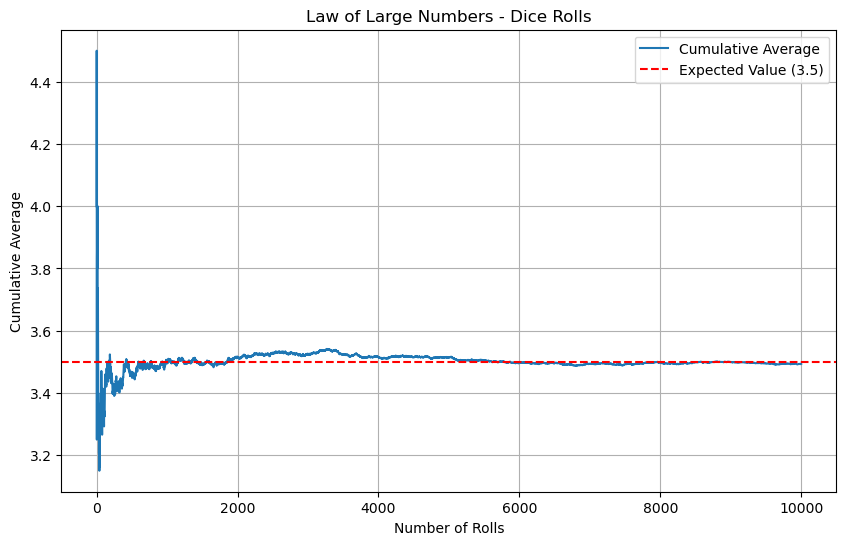

In [2]:
# Number of trials
num_trials = 10000

# Simulate dice rolls
dice_rolls = np.random.randint(1, 7, size=num_trials)

# Compute cumulative averages
cumulative_averages = np.cumsum(dice_rolls) / np.arange(1, num_trials + 1)

# Plot the convergence
plt.figure(figsize=(10, 6))
plt.plot(cumulative_averages, label="Cumulative Average")
plt.axhline(y=3.5, color='r', linestyle='--', label="Expected Value (3.5)")
plt.title("Law of Large Numbers - Dice Rolls")
plt.xlabel("Number of Rolls")
plt.ylabel("Cumulative Average")
plt.legend()
plt.grid()
plt.show()

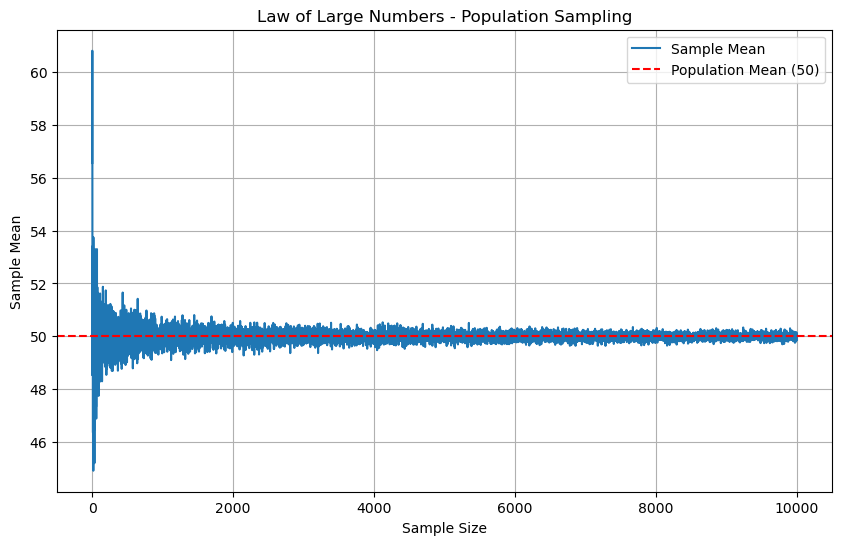

In [3]:
# Generate a population
population_mean = 50
population_std = 10
population = np.random.normal(loc=population_mean, scale=population_std, size=100000)

# Draw increasing sample sizes and compute means
sample_sizes = np.arange(1, 10001)
sample_means = [np.mean(np.random.choice(population, size=n)) for n in sample_sizes]

# Plot the convergence
plt.figure(figsize=(10, 6))
plt.plot(sample_sizes, sample_means, label="Sample Mean")
plt.axhline(y=population_mean, color='r', linestyle='--', label="Population Mean (50)")
plt.title("Law of Large Numbers - Population Sampling")
plt.xlabel("Sample Size")
plt.ylabel("Sample Mean")
plt.legend()
plt.grid()
plt.show()


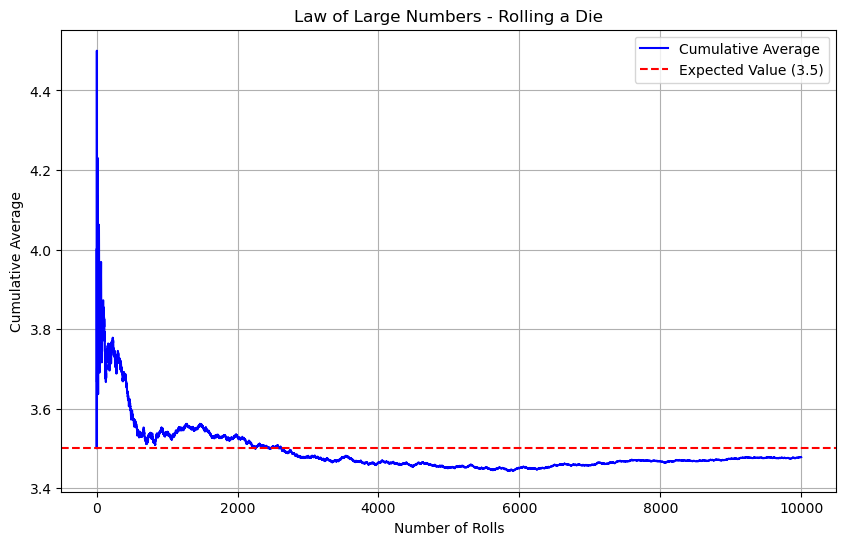

In [4]:
# Number of rolls
num_rolls = 10000

# Simulate die rolls
rolls = np.random.randint(1, 7, size=num_rolls)

# Calculate cumulative averages
cumulative_averages = np.cumsum(rolls) / np.arange(1, num_rolls + 1)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(cumulative_averages, label="Cumulative Average", color="blue")
plt.axhline(y=3.5, color='red', linestyle='--', label="Expected Value (3.5)")
plt.title("Law of Large Numbers - Rolling a Die")
plt.xlabel("Number of Rolls")
plt.ylabel("Cumulative Average")
plt.legend()
plt.grid()
plt.show()


#### `Observations`
1. In both simulations, as the sample size increases:
   - The sample mean converges to the true population mean (or expected value).
2. The convergence is faster for distributions with less variability.
3. The LLN demonstrates that larger samples are more reliable for estimating population parameters.


___
[Back to the top](#table-of-contents)

<a id="central-limit-theorem"></a>

# 📈 Central Limit Theorem

<details><summary><strong>📖 Click to Expand</strong></summary>

<p>The <strong>Central Limit Theorem (CLT)</strong> is a fundamental concept in statistics that explains the behavior of sample means when drawing random samples from a population. The Central Limit Theorem states that:</p>

<ol>
  <li>When you take random samples of size \(n\) from a population with any distribution (e.g., skewed, uniform, etc.), the distribution of the sample means will tend to be approximately normal (bell-shaped) as the sample size becomes large.</li>
  <li>This result holds regardless of the shape of the population distribution.</li>
</ol>

<h5>📌 Key Components</h5>
<ul>
  <li><strong>Population Mean (μ):</strong> The average value in the population.</li>
  <li><strong>Population Standard Deviation (σ):</strong> The spread or variability in the population.</li>
  <li><strong>Sample Mean (x̄):</strong> The average value in a random sample.</li>
  <li><strong>Sampling Distribution of the Sample Mean:</strong> The distribution of sample means from all possible samples of size \( n \).</li>
</ul>

<h5>❓ Why is the CLT Important?</h5>
<ol>
  <li>It allows us to use the properties of the normal distribution even if the population distribution is unknown or non-normal.</li>
  <li>It provides the foundation for many statistical methods, including hypothesis testing and confidence intervals.</li>
  <li>It ensures that sample means are predictable and centered around the population mean.</li>
</ol>

<h5>✅ Conditions for the CLT</h5>
<ol>
  <li>The samples must be <strong>randomly selected</strong>.</li>
  <li>The sample size (\(n\)) should be sufficiently large. As a rule of thumb, \(n > 30\) is often sufficient, but heavily skewed distributions may require larger samples.</li>
  <li>The samples should be <strong>independent</strong> of each other.</li>
</ol>

<h5>📐 Formula for Standard Error of the Mean</h5>

<p>The standard deviation of the sampling distribution of the sample mean, known as the <strong>Standard Error (SE)</strong>, is given by:</p>

$$
SE = \frac{\sigma}{\sqrt{n}}
$$

<p>Where:</p>
<ul>
  <li>\(\sigma\): The standard deviation of the population.</li>
  <li>\(n\): The sample size.</li>
</ul>

</details>


In [5]:
# Parameters
population_mean = 35  # The mean (average) value of the simulated population.
population_std = 15 # The standard deviation of the population, indicating how spread out.
sample_size = 50 # The number of individuals (data points) in each random sample drawn from the population.
num_samples = 10000 # The total number of samples to draw from the population.
num_bins = 30 # The number of bins (intervals) used to create histograms for visualizing the distributions.

In [6]:
# Distributions to plot
distributions = {
    "Exponential": lambda: np.random.exponential(scale=population_std, size=100000) + population_mean,
    "Uniform": lambda: np.random.uniform(low=population_mean - 3*population_std, 
                                         high=population_mean + 3*population_std, size=100000),
    "Normal": lambda: np.random.normal(loc=population_mean, scale=population_std, size=100000),
    "Lognormal": lambda: np.random.lognormal(mean=np.log(population_mean), sigma=0.5, size=100000),
    "Poisson": lambda: np.random.poisson(lam=population_mean, size=100000),
    "Chi-Square": lambda: np.random.chisquare(df=10, size=100000),
    "Beta": lambda: np.random.beta(a=2, b=5, size=100000) * 70  # Scale beta for a better range
}

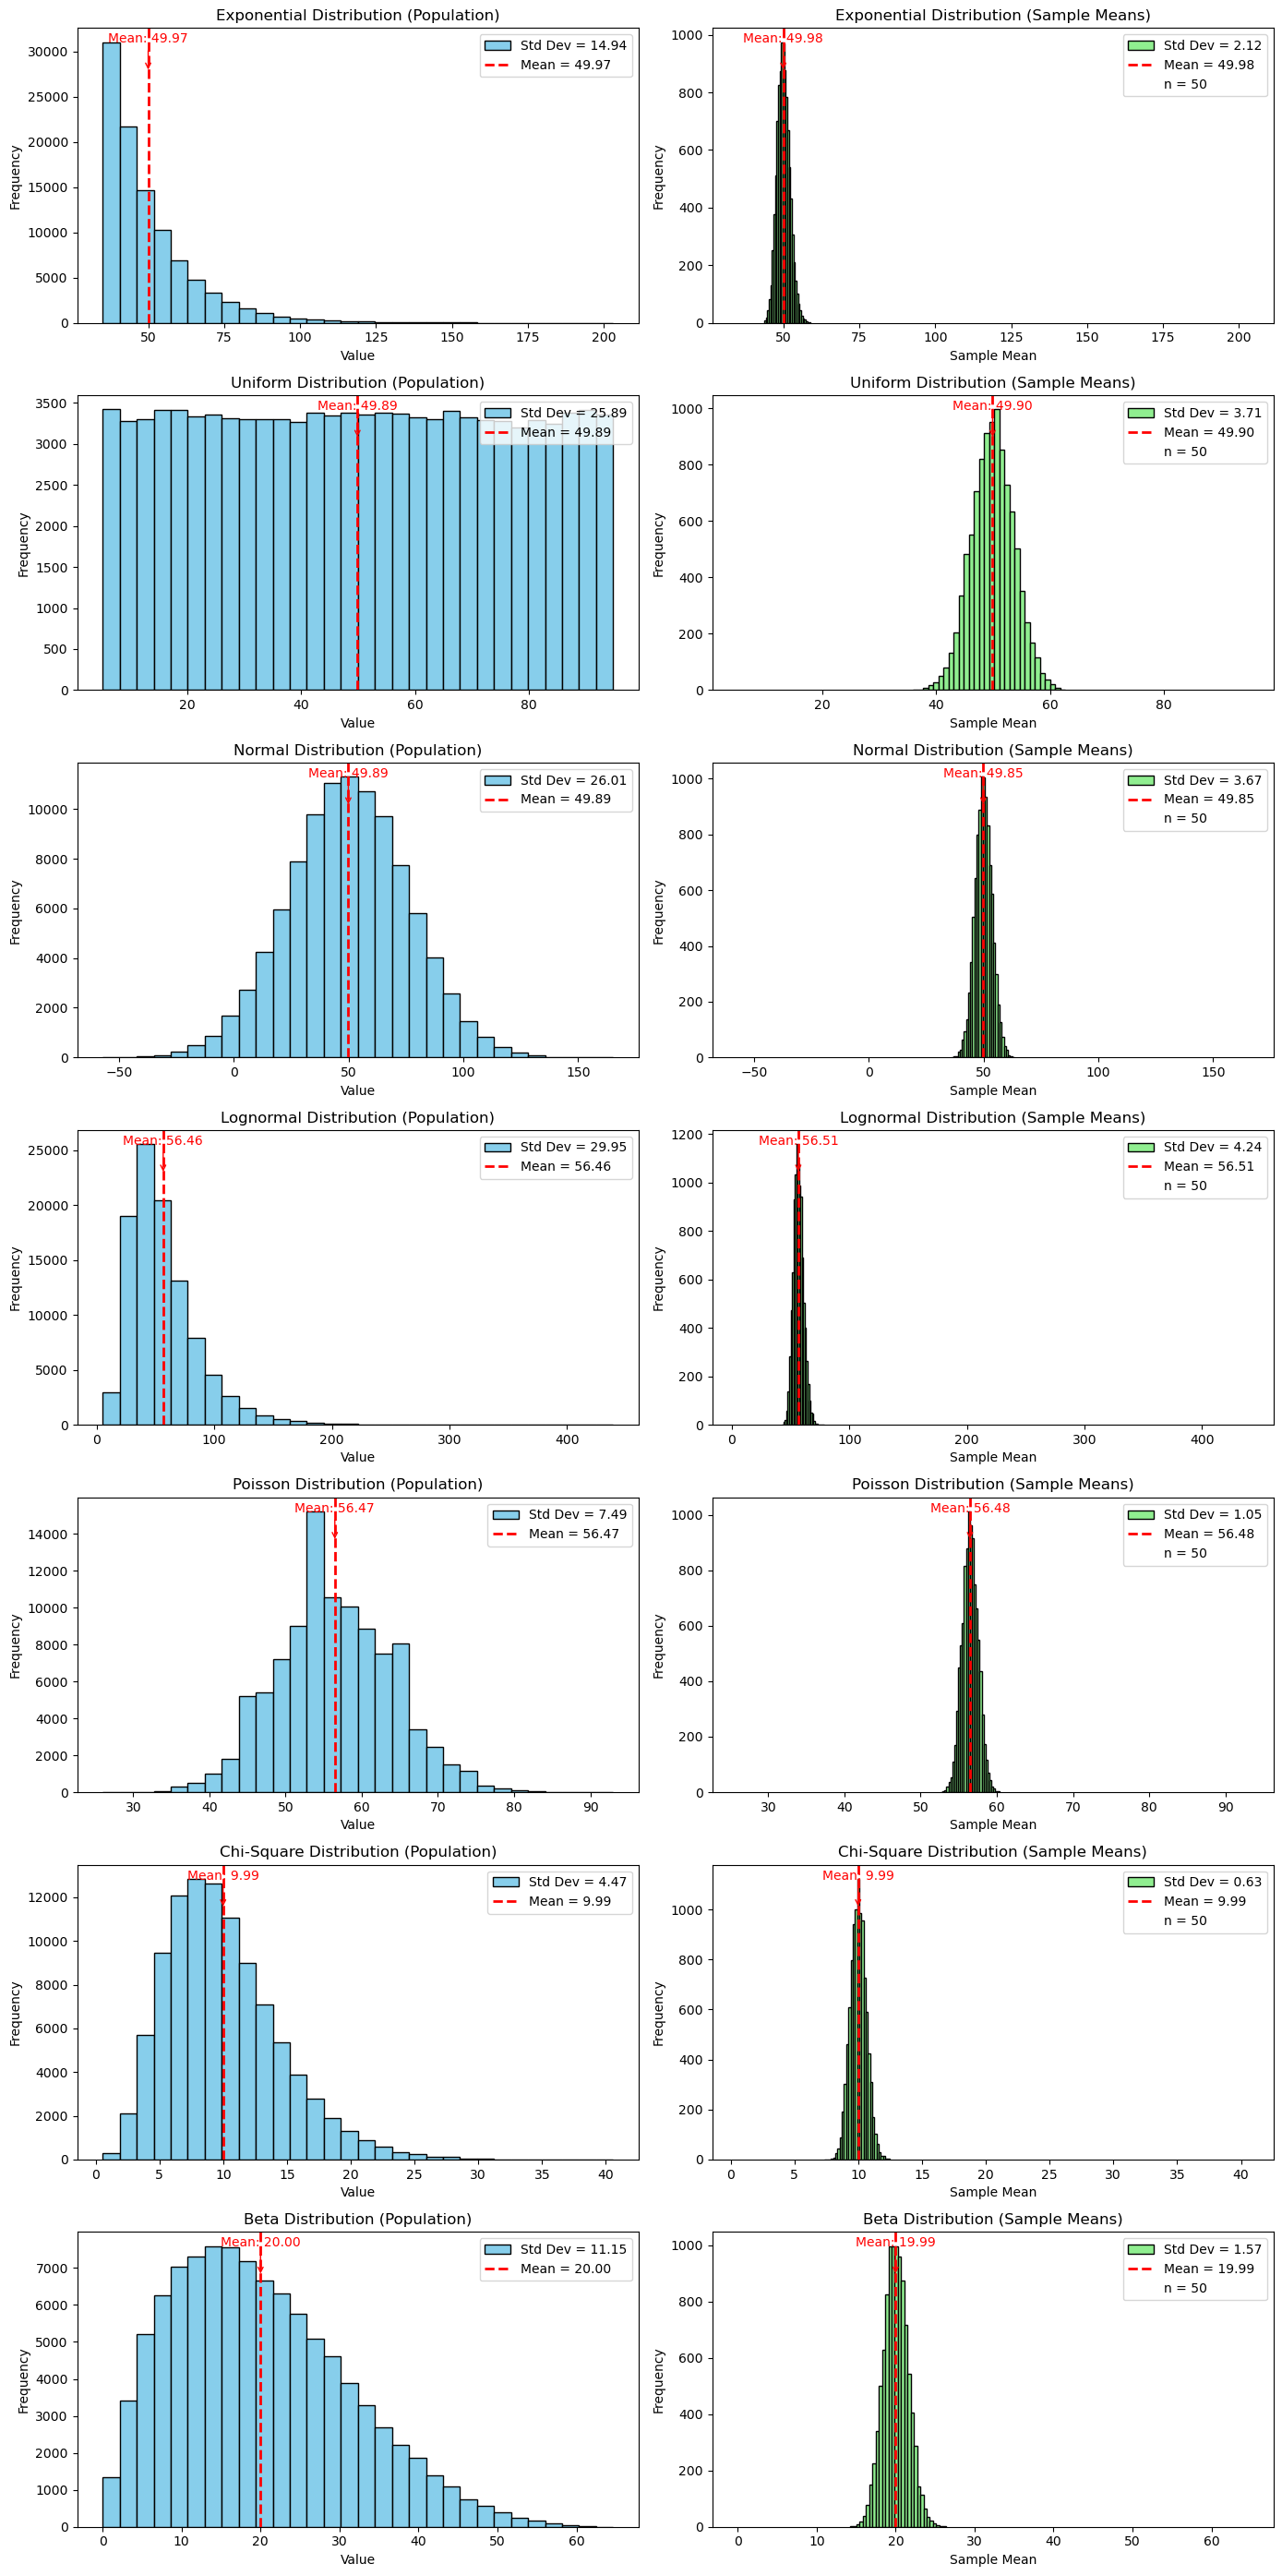

In [7]:
# Initialize the figure
fig, axes = plt.subplots(
    len(distributions),
    2,
    figsize=(14, 4 * len(distributions)),
    sharex="row"
)

# Iterate through distributions
for i, (dist_name, dist_func) in enumerate(distributions.items()):
    # Generate population data
    population = dist_func()

    # Collect sample means
    sample_means = np.array([
        np.mean(np.random.choice(population, sample_size))
        for _ in range(num_samples)
    ])

    # Calculate stats
    population_mean = np.mean(population)
    population_std = np.std(population)

    sample_means_mean = np.mean(sample_means)
    sample_means_std = np.std(sample_means)

    # Plot the population distribution
    axes[i, 0].hist(
        population,
        bins=num_bins,
        color="skyblue",
        edgecolor="black",
        label=f"Std Dev = {population_std:.2f}"
    )
    axes[i, 0].axvline(
        population_mean,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Mean = {population_mean:.2f}"
    )
    axes[i, 0].annotate(
        f"Mean: {population_mean:.2f}",
        xy=(population_mean, axes[i, 0].get_ylim()[1] * 0.85),
        xytext=(population_mean, axes[i, 0].get_ylim()[1] * 0.95),
        ha="center",
        color="red",
        arrowprops=dict(arrowstyle="->", color="red")
    )
    axes[i, 0].set_title(f"{dist_name} Distribution (Population)")
    axes[i, 0].set_xlabel("Value")
    axes[i, 0].set_ylabel("Frequency")
    axes[i, 0].legend(loc="upper right")

    # Plot the sample means distribution
    axes[i, 1].hist(
        sample_means,
        bins=num_bins,
        color="lightgreen",
        edgecolor="black",
        label=f"Std Dev = {sample_means_std:.2f}"
    )
    axes[i, 1].axvline(
        sample_means_mean,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Mean = {sample_means_mean:.2f}"
    )
    axes[i, 1].annotate(
        f"Mean: {sample_means_mean:.2f}",
        xy=(sample_means_mean, axes[i, 1].get_ylim()[1] * 0.85),
        xytext=(sample_means_mean, axes[i, 1].get_ylim()[1] * 0.95),
        ha="center",
        color="red",
        arrowprops=dict(arrowstyle="->", color="red")
    )

    # Add invisible legend entry for CLT sample size n
    axes[i, 1].plot([], [], " ", label=f"n = {sample_size}")

    axes[i, 1].set_title(f"{dist_name} Distribution (Sample Means)")
    axes[i, 1].set_xlabel("Sample Mean")
    axes[i, 1].set_ylabel("Frequency")
    axes[i, 1].legend(loc="upper right")

plt.tight_layout()
plt.show()

___
[Back to the top](#table-of-contents)

<a id="chebyshevs-inequality"></a>

# 🎯 Chebyshev’s Inequality


<details><summary><strong>📖 Click to Expand</strong></summary>

Chebyshev’s Inequality provides a lower bound on how much of the data lies within a certain number of standard deviations from the mean—**regardless of the distribution**.

##### 🧠 Theorem  
For any random variable with finite mean $\mu$ and standard deviation $\sigma$:

$$
P(|X - \mu| \geq k\sigma) \leq \frac{1}{k^2}
$$

Equivalently:

$$
P(|X - \mu| < k\sigma) \geq 1 - \frac{1}{k^2}
$$

##### 💡 Why It Matters in Data Science
- **Distribution-free**: Works without assuming normality  
- **Conservative bound**: Guarantees a minimum % of data near the mean  
- **Use cases**:  
  - Outlier detection  
  - Sanity checks in pipelines  
  - Debugging skewed or unknown data distributions  

##### `Key Thresholds`

| k (σ) | Minimum % of data within ±kσ |
|-------|-------------------------------|
| 1     | 0%                            |
| 2     | 75%                           |
| 3     | 88.9%                         |
| 4     | 93.75%                        |
| 5     | 96%                           |
</details>

In [8]:
# Set seed for reproducibility
np.random.seed(0)

# Simulate a non-normal distribution: exponential
data = np.random.exponential(scale=1.0, size=10_000)

# Compute mean and standard deviation
mu = np.mean(data)
sigma = np.std(data)

print(f"Simulated a non-normal dataset (exponential).")
print(f"Mean (μ): {mu:.2f}")
print(f"Standard Deviation (σ): {sigma:.2f}")


Simulated a non-normal dataset (exponential).
Mean (μ): 0.99
Standard Deviation (σ): 1.00


In [9]:
# Define k values
k_values = np.arange(1, 6)

# Empirical proportions within ±kσ
empirical_props = [(np.abs(data - mu) < k * sigma).mean() for k in k_values]

# Chebyshev lower bounds
chebyshev_bounds = [1 - 1 / (k ** 2) for k in k_values]

print("Proportion of data within ±k standard deviations vs Chebyshev bound:")
print(f"{'k':<5} {'Empirical Proportion':<25} {'Chebyshev Bound':<20}")
for k, emp, bound in zip(k_values, empirical_props, chebyshev_bounds):
    print(f"{k:<5} {emp:<25.3f} {bound:<20.3f}")


Proportion of data within ±k standard deviations vs Chebyshev bound:
k     Empirical Proportion      Chebyshev Bound     
1     0.864                     0.000               
2     0.950                     0.750               
3     0.983                     0.889               
4     0.994                     0.938               
5     0.998                     0.960               


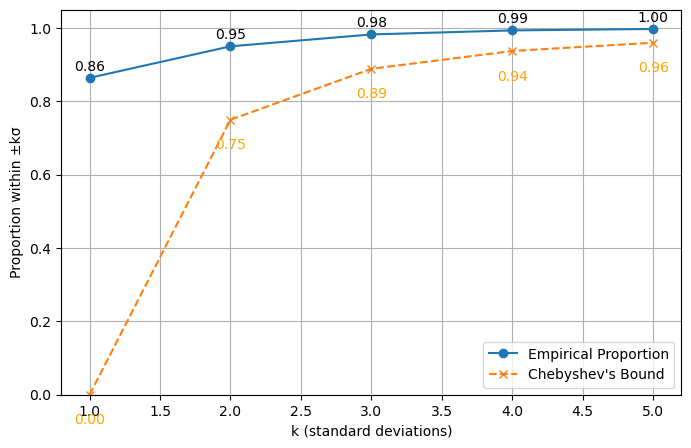

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, empirical_props, marker='o', label='Empirical Proportion')
plt.plot(k_values, chebyshev_bounds, marker='x', linestyle='--', label="Chebyshev's Bound")
for i, k in enumerate(k_values):
    plt.text(k, empirical_props[i] + 0.02, f"{empirical_props[i]:.2f}", ha='center')
    plt.text(k, chebyshev_bounds[i] - 0.08, f"{chebyshev_bounds[i]:.2f}", ha='center', color='orange')
plt.xlabel("k (standard deviations)")
plt.ylabel("Proportion within ±kσ")
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.show()


#### 🧠 `Observations`

- The actual proportion of data within ±kσ is **consistently higher** than Chebyshev's bound.
- Chebyshev’s inequality gives a **conservative lower bound** — it guarantees *at least* that much mass, not the exact amount.
- This simulation uses a **non-normal**, skewed distribution (exponential), demonstrating the usefulness of Chebyshev when normality can't be assumed.
- In practice, you can use this to **spot check variability** or **flag outliers** even when the distribution is unknown.


___
[Back to the top](#table-of-contents)

<a id="bayes-theorem"></a>

# 🔁 Bayes' Theorem

<details><summary><strong>📖 Click to Expand</strong></summary>

Bayes' Theorem helps us **update the probability of a belief or event** when new evidence is introduced.  

It's the formal way of answering:  
> "Given what I already believe, and this new info I just saw, what should I believe now?"

##### 🧠 Theorem
$$
P(A \mid B) = \frac{P(B \mid A) \cdot P(A)}{P(B)}
$$

Where:  
- `P(A)`: Prior — what you believed before  
- `P(B | A)`: Likelihood — how likely the evidence is if A is true  
- `P(B)`: Evidence — how likely the evidence is overall  
- `P(A | B)`: Posterior — what you believe *after* seeing the evidence

##### 💡 Why It Matters
- Lets you **adjust probability estimates** as new data arrives  
- Common in fraud detection, medical diagnosis, spam filters, and **A/B testing with priors**  
- Helps make **data-informed decisions under uncertainty**

##### 🧩 `Bayes' Theorem Components`

| Term         | Meaning                                                |
|--------------|--------------------------------------------------------|
| Prior        | Your initial belief before seeing any new evidence     |
| Likelihood   | How well the new evidence fits with that belief        |
| Evidence     | The overall probability of seeing the evidence         |
| Posterior    | Your updated belief after incorporating the evidence   |

##### 🏢 `Business Relevance`
Bayes' Theorem is widely used in real-world decision-making, especially when working with uncertainty or limited data.

Typical examples:
- **Spam Detection**: Update probability that an email is spam based on keywords or sender
- **Medical Diagnosis**: Revise probability of a disease given a positive test
- **A/B Testing**: Apply prior belief about variant performance, update as results come in
- **Fraud Detection**: Adjust likelihood of fraud based on new transaction behavior

In all these cases, Bayes' helps answer:
> “Given what we believed, and what we just saw — how should we think now?”


</details>

In [11]:
# Example: Medical testing for a rare disease
# Given:
# - 1% of people have the disease (Prior)
# - Test is 90% sensitive (true positive rate)
# - Test is 95% specific (true negative rate)
# - A person tests positive. What's the probability they actually have the disease?

prior = 0.01
sensitivity = 0.90         # P(Positive | Disease)
specificity = 0.95         # P(Negative | No Disease)
false_positive = 1 - specificity

# P(Positive)
evidence = (sensitivity * prior) + (false_positive * (1 - prior))

# P(Disease | Positive)
posterior = (sensitivity * prior) / evidence

# Business-friendly output
print("🔍 Medical Testing Example")
print(f"Chance of disease before test: {prior:.2%}")
print(f"Chance of actually having disease after positive test: {posterior:.2%}")


🔍 Medical Testing Example
Chance of disease before test: 1.00%
Chance of actually having disease after positive test: 15.38%


In [12]:
def bayes_update(prior, sensitivity, specificity):
    """
    Compute posterior probability using Bayes' Theorem.
    
    Parameters:
    - prior: P(Disease), base rate
    - sensitivity: P(Positive | Disease)
    - specificity: P(Negative | No Disease)
    
    Returns:
    - posterior: P(Disease | Positive)
    """
    false_positive = 1 - specificity
    evidence = (sensitivity * prior) + (false_positive * (1 - prior))
    posterior = (sensitivity * prior) / evidence
    return posterior

# Example run
posterior = bayes_update(prior=0.01, sensitivity=0.90, specificity=0.95)

# Interpretation print block
print("📊 Bayesian Update")
print(f"🧠 Prior belief (base rate): {0.01:.2%}")
print(f"✅ Sensitivity (true positive rate): {0.90:.2%}")
print(f"❌ False positive rate: {1 - 0.95:.2%}")
print(f"\n📈 Updated belief after a positive test: {posterior:.2%}")
print(f"\n🧾 Interpretation:")
print(f"Out of 100 people who test positive, about {posterior * 100:.1f} are actually positive.")


📊 Bayesian Update
🧠 Prior belief (base rate): 1.00%
✅ Sensitivity (true positive rate): 90.00%
❌ False positive rate: 5.00%

📈 Updated belief after a positive test: 15.38%

🧾 Interpretation:
Out of 100 people who test positive, about 15.4 are actually positive.


In [13]:
# Varying the prior to see its impact on the posterior
priors = [0.001, 0.01, 0.05, 0.1, 0.25]
sensitivity = 0.90
specificity = 0.95

print("🎯 How prior belief affects the updated probability after a positive test:")
print(f"{'Prior':<10} {'Posterior':<15} {'Interpretation'}")
for p in priors:
    post = bayes_update(p, sensitivity, specificity)
    print(f"{p:<10.3f} {post:<15.3f} About {post * 100:.1f} out of 100 positives are truly positive")


🎯 How prior belief affects the updated probability after a positive test:
Prior      Posterior       Interpretation
0.001      0.018           About 1.8 out of 100 positives are truly positive
0.010      0.154           About 15.4 out of 100 positives are truly positive
0.050      0.486           About 48.6 out of 100 positives are truly positive
0.100      0.667           About 66.7 out of 100 positives are truly positive
0.250      0.857           About 85.7 out of 100 positives are truly positive


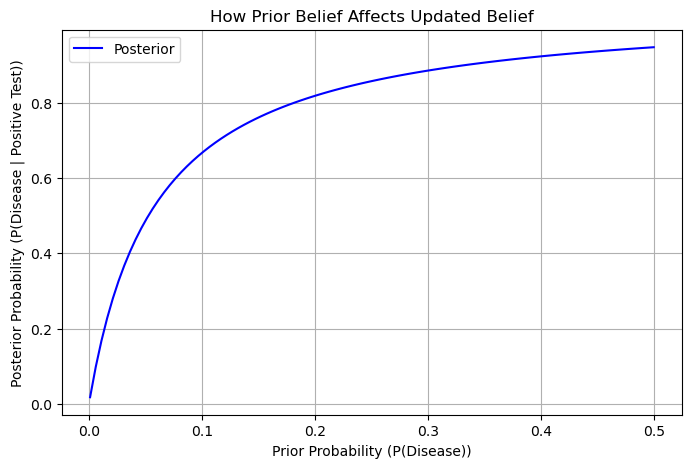

In [14]:
import matplotlib.pyplot as plt

# Prepare data
priors = np.linspace(0.001, 0.5, 100)
posteriors = [bayes_update(p, sensitivity, specificity) for p in priors]

# Plot
plt.figure(figsize=(8, 5))
plt.plot(priors, posteriors, label="Posterior", color='blue')
plt.xlabel("Prior Probability (P(Disease))")
plt.ylabel("Posterior Probability (P(Disease | Positive Test))")
plt.title("How Prior Belief Affects Updated Belief")
plt.grid(True)
plt.legend()
plt.show()


##### 🧠 `Observations & Takeaways`

- Bayes’ Theorem shows that **initial belief (prior)** heavily influences the final result.
- For **rare events**, even a positive test doesn't mean high certainty — most positives are false.
- The more confident your prior, the more evidence you need to overturn it.
- This is why Bayes is powerful: it lets you **balance prior knowledge with new evidence**.
- Business implication: **Don't blindly trust model outputs** — always consider the base rate.



___
[Back to the top](#table-of-contents)